# What is the most optimal skill to learn for Top 5 Roles?

## Methodology
1. Continue from last notebook to find percent of postings with skill
2. Visualize median salary vs percent skill demand
3. (Optional) Determine if certain technologies are more prevalent

## Import Libraries and Dataset

In [2]:
#Turn off warning notification
import warnings
warnings.filterwarnings("ignore")

import datasets
datasets.logging.set_verbosity_error()

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from matplotlib.ticker import PercentFormatter

#Load dataset 
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df.job_posted_date = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## Clean Data

Filters the original dataset to get only rows where the job title is the top 5 roles, which have the most job postings and the countries belong to Southeast Asia. Then it uses explode method on job_skills column to create new rows in a new DataFrame (df_SEA_exploded) for each skill associated with a job.

In [4]:
# Countries belong to Southeast Asia
countries = ['Brunei', 'Cambodia', 'Indonesia', 'Laos', 'Malaysia' , 'Myanmar'
             , 'Philippines', 'Singapore', 'Thailand', 'East Timor', 'Vietnam']

In [ ]:
df_SEA = df[(df['job_country'].isin(countries))].copy()

# Calculating the median salary
median_salary = df_SEA['salary_year_avg'].median()

# Filling the missing values with the median salary to keep the DataFrame intact
df_SEA['salary_year_avg'] = df_SEA['salary_year_avg'].fillna(median_salary)

Create a list of the top 5 job_titles and filter our dataframe to only contain these job titles

In [8]:
job_titles = df_SEA['job_title_short'].value_counts().head(5).index

# Filter the df for top 5 job title:
df_SEA = df_SEA[df_SEA['job_title_short'].isin(job_titles)]

df_SEA_exploded = df_SEA.explode('job_skills')

df_SEA_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
44,90670.0,python
44,90670.0,java
44,90670.0,scala
76,90670.0,sql
76,90670.0,python


## Calculate Percent of Job Postings that Have Skills

Group the data by job skills and calculates the count and mean salary for each skill, sorting the results in descending order by count. It then renames the columns. Calculates the percentage that each skill count represents out of the total number of Top 5 Roles.Finally, filter out any skills that don't have any jobs associated with them.

In [21]:
# using ds_SEA find the count of skills and also the mean salary for each skill
df_SEA_skills = df_SEA_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'mean']).sort_values(by='count', ascending=False)

df_SEA_skills = df_SEA_skills.rename(columns = {'count': 'skill_count', 'mean': 'mean_salary'})

SEA_job_count = len(df_SEA) # Find count of Top 5 jobs in SEA with salary info

df_SEA_skills['skill_percent'] = df_SEA_skills['skill_count'] / SEA_job_count * 100

df_SEA_skills = df_SEA_skills[df_SEA_skills['skill_percent'] > 0]

df_SEA_skills 

,skill_count,mean_salary,skill_percent
job_skills,,,
sql,21160,90715.003686,10.897106
python,18504,90741.173719,9.529303
excel,10626,90643.575899,5.472242
tableau,8406,90680.167380,4.328973
power bi,6414,90729.983162,3.303121
...,...,...,...
f#,1,90670.000000,0.000515
rocketchat,1,90670.000000,0.000515
shogun,1,90670.000000,0.000515


## Mean Salary vs Percent Skill Demand

Filters for skills of Top 5 roles that exceed a certain percentage (skill_limit).

In [24]:
skill_limit = 2

df_SEA_skills_high_demand = df_SEA_skills[df_SEA_skills['skill_percent'] > skill_limit]

Create a scatter plot to visualize the relationship between the percentage of Top 5 roles that require specific skills and the mean salary for those skills

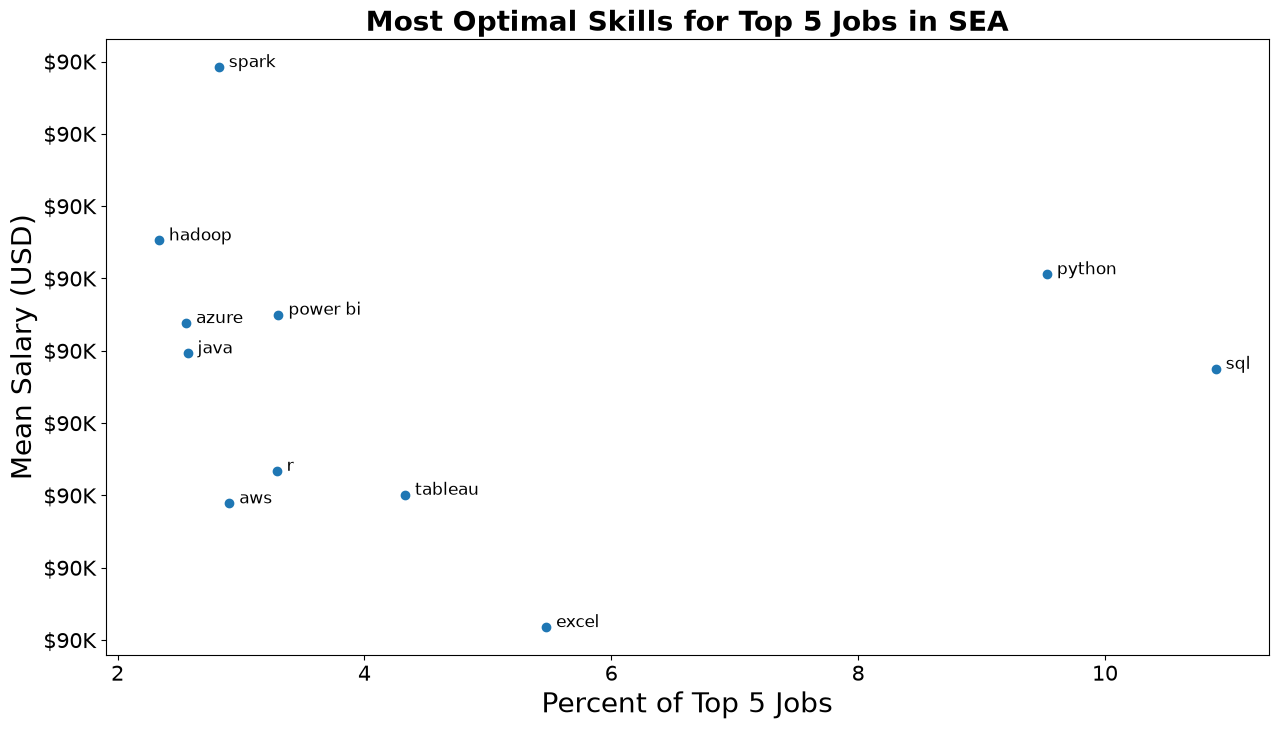

In [62]:
from adjustText import adjust_text

plt.figure(figsize=(15, 8))
plt.scatter(
            df_SEA_skills_high_demand['skill_percent']
            , df_SEA_skills_high_demand['mean_salary'])

plt.xlabel(
            'Percent of Top 5 Jobs'
            , fontdict={'fontsize': 20})

plt.ylabel(
            'Mean Salary (USD)'
            , fontdict={'fontsize': 20})

plt.title(
            'Most Optimal Skills for Top 5 Jobs in SEA'
            , fontdict={'fontsize': 20, 'fontweight': 'bold'})

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K'))

ax.tick_params(axis='x', labelsize = 15)
ax.tick_params(axis='y', labelsize = 15)

# Add labels to points and collect them in a list
texts = []
for index, text in enumerate(df_SEA_skills_high_demand.index):
    texts.append(plt.text(
                            df_SEA_skills_high_demand['skill_percent'].iloc[index]
                            , df_SEA_skills_high_demand['mean_salary'].iloc[index]
                            , "  " + text
                            , fontdict={'fontsize': 12}))

plt.show()

## Coloring by Technology

We're going to add color labels based on technology

Removes duplicate entries and any rows with missing values. Then, it combines all dictionary entries into a single dictionary, summing values for keys that repeat across entries. To ensure each key's values are unique, it converts the values to a set and then back to a list. Ultimately, the result is a dictionary where key represents a skill and each value is a list of unique attributes associated with that skill

In [51]:
df_tech = df['job_type_skills'].copy()

# Remove duplicates
df_tech = df_tech.drop_duplicates()

# Remove NaN values
df_tech = df_tech.dropna()

# Combine all dictionaries into open
tech_dict = {}

for row in df_tech:
    row_dict = ast.literal_eval(row) # Convert string into dictionary
    for key, value in row_dict.items():
        if key in tech_dict:
            tech_dict[key] += value # If key exists in tech_dict, add value to existing value
        else:
            tech_dict[key] = value

# Reomve duplicates by converting values to set then back to list
for key, value in tech_dict.items():
    tech_dict[key] = list(set(value))

tech_dict

{'analyst_tools': ['powerpoint',
  'visio',
  'looker',
  'splunk',
  'sap',
  'esquisse',
  'dax',
  'nuix',
  'tableau',
  'spss',
  'alteryx',
  'sharepoint',
  'powerbi',
  'qlik',
  'outlook',
  'ssrs',
  'cognos',
  'datarobot',
  'sheets',
  'msaccess',
  'ssis',
  'power bi',
  'spreadsheet',
  'microstrategy',
  'word',
  'sas',
  'ms access',
  'excel'],
 'programming': ['no-sql',
  'c',
  'javascript',
  'mongodb',
  'shell',
  'delphi',
  'lisp',
  'c++',
  'vba',
  'java',
  'julia',
  'sql',
  'go',
  'cobol',
  'nosql',
  'golang',
  'swift',
  'assembly',
  'erlang',
  'powershell',
  'visual basic',
  'r',
  'kotlin',
  'visualbasic',
  'ruby',
  't-sql',
  'scala',
  'perl',
  'groovy',
  'c#',
  'lua',
  'sass',
  'typescript',
  'ocaml',
  'clojure',
  'apl',
  'rust',
  'bash',
  'pascal',
  'mongo',
  'fortran',
  'objective-c',
  'elixir',
  'haskell',
  'sas',
  'python',
  'dart',
  'html',
  'solidity',
  'vb.net',
  'crystal',
  'php',
  'css',
  'matlab',
  

This code converts a dictionary into a pandas DataFrame, then explodes the 'skills' column, creating multiple rows for each 'technology' entry if it contains multiple skills.

In [56]:
# Turn dictionary into DataFrame
df_tech = pd.DataFrame(list(tech_dict.items()), columns=['technology', 'skills'])

df_tech = df_tech.explode('skills')

df_tech

,technology,skills
0,analyst_tools,powerpoint
0,analyst_tools,visio
0,analyst_tools,looker
0,analyst_tools,splunk
0,analyst_tools,sap
...,...,...
9,sync,twilio
9,sync,slack
9,sync,google chat
9,sync,microsoft teams


Merge two DataFrames, df_SEA_skills and df_tech, based on the colums 'job_skills' and 'skills' respectively, creating a new DataFrame df_SEA_skills_tech

In [60]:
# Merge df_SEA_skills and df_tech
df_SEA_skills_tech = df_SEA_skills.merge(df_tech, left_on='job_skills', right_on='skills')

df_SEA_skills_tech

,skill_count,mean_salary,skill_percent,technology,skills
0,21160,90715.003686,10.897106,programming,sql
1,18504,90741.173719,9.529303,programming,python
2,10626,90643.575899,5.472242,analyst_tools,excel
3,8406,90680.167380,4.328973,analyst_tools,tableau
4,6414,90729.983162,3.303121,analyst_tools,power bi
5,6386,90686.805747,3.288701,programming,r
6,5641,90677.802695,2.905037,cloud,aws
7,5476,90798.449872,2.820064,libraries,spark
8,4985,90719.294483,2.567206,programming,java
9,4962,90727.663543,2.555361,cloud,azure


Filters df_SEA_skills_tech to select rows where the 'percent' column exceeds a specified threshold, storing the result in df_SEA_skills_tech_high_demand

In [61]:
df_SEA_skills_tech_high_demand = df_SEA_skills_tech[df_SEA_skills_tech['skill_percent'] > skill_limit]

Plot the result in a scatter plot, coloring the points based on the 'technology' column.

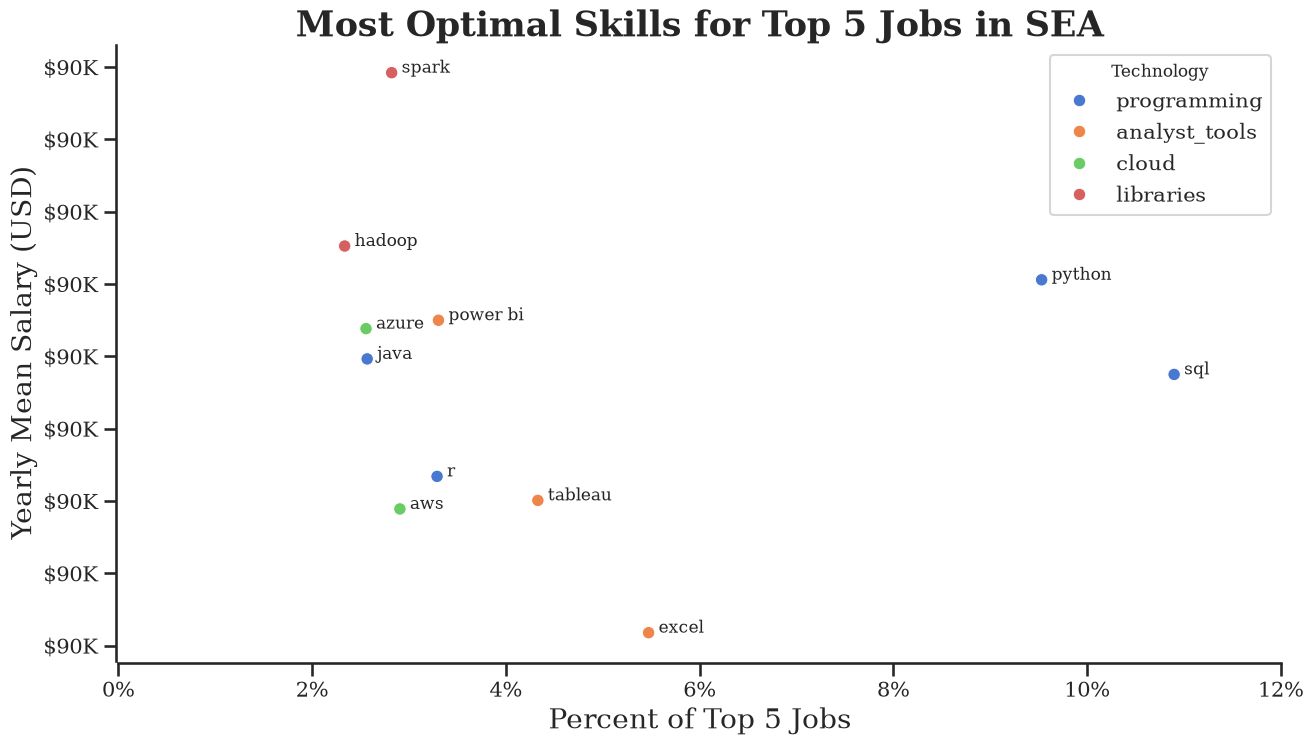

In [88]:
fig, ax = plt.subplots(figsize = (15, 8))

sns.set_theme(
                style='ticks'
                , palette = 'muted'
                , context="talk"
                , font = 'serif'
                , font_scale = 0.7)

sns.scatterplot(
                data=df_SEA_skills_tech_high_demand
                , x = 'skill_percent'
                , y = 'mean_salary'
                , hue = 'technology')

sns.despine(offset=2)

# Set axis labels, title, and legend
plt.title(
            'Most Optimal Skills for Top 5 Jobs in SEA'
            , fontdict={'fontsize': 25, 'fontweight': 'bold'})

plt.xlabel(
            'Percent of Top 5 Jobs'
            , fontdict={'fontsize': 20}
            , loc = 'center')

plt.ylabel(
            'Yearly Mean Salary (USD)'
            , fontdict={'fontsize': 20})

for index, txt in enumerate(df_SEA_skills_tech_high_demand['skills'].values):
    plt.text(
            df_SEA_skills_tech_high_demand['skill_percent'].iloc[index]
            , df_SEA_skills_tech_high_demand['mean_salary'].iloc[index]
            , "  " + txt)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000):,}K'))
plt.gca().xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.gca().tick_params(axis='x', labelsize = 15)
plt.gca().tick_params(axis='y', labelsize = 15)

plt.legend(
            title='Technology'
            , fontsize = 15)
plt.xlim(0, 12)

plt.show()